In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("..\\datasets\\pouco_padronizado.csv", encoding='utf-8', low_memory=True)


In [18]:
X = df.drop(columns=['popular_60', 'popular_70', 'popular_80', 'popular_90'])
Y = df['popular_60']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [12]:
target_60 = df['popular_60']
target_70 = df['popular_70']
target_80 = df['popular_80']
target_90 = df['popular_90']

targets = [target_60, target_70, target_80, target_90]

In [5]:
svm = SVC(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=8.15  # 57.964 / 7.111
)
knn = KNeighborsClassifier()

In [7]:
f1_scorer_popular = make_scorer(f1_score, pos_label=1)

In [9]:
# param grid

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

param_grid_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [10]:
grid_svm = GridSearchCV(svm, param_grid_svm, scoring=f1_scorer_popular, cv=5, n_jobs=-1, verbose=2)
grid_rf = GridSearchCV(rf, param_grid_rf, scoring=f1_scorer_popular, cv=5, n_jobs=-1, verbose=2)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring=f1_scorer_popular, cv=5, n_jobs=-1, verbose=2)
grid_knn = GridSearchCV(knn, param_grid_knn, scoring=f1_scorer_popular, cv=5, n_jobs=-1, verbose=2)

In [14]:
svm_basico = svm
svm_basico.fit(x_train, y_train)

SVC(class_weight='balanced', random_state=42)

In [20]:
rf_basico = rf
rf_basico.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [15]:
nome_modelo = "SVM Básico"
modelo = svm_basico

Matriz de Confusão (Teste - SVM Básico):
[[8133 7595]
 [ 154  387]]


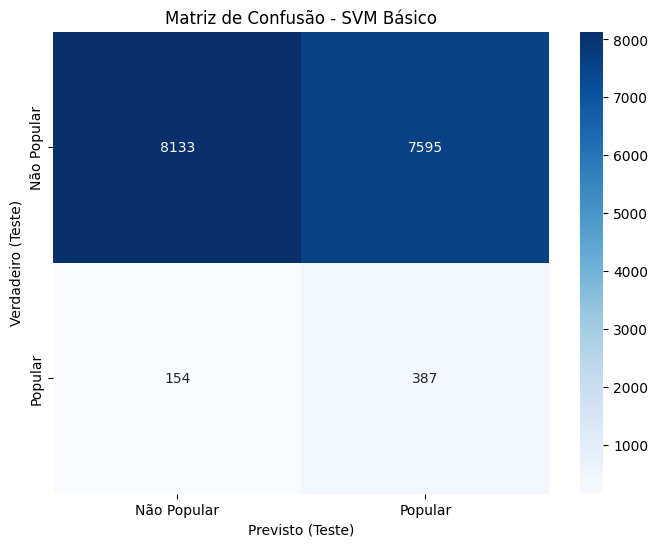


Métricas de Classificação (Teste - SVM Básico:
              precision    recall  f1-score   support

 Não Popular       0.98      0.52      0.68     15728
     Popular       0.05      0.72      0.09       541

    accuracy                           0.52     16269
   macro avg       0.51      0.62      0.38     16269
weighted avg       0.95      0.52      0.66     16269



In [16]:
y_pred = modelo.predict(x_test)  

# Calcula a matriz de confusão comparando os rótulos reais e os previstos no teste
conf_matrix_modelo = confusion_matrix(y_test, y_pred)
print(f"Matriz de Confusão (Teste - {nome_modelo}):")
print(conf_matrix_modelo)

# Cria uma figura para exibir graficamente a matriz de confusão do teste
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_modelo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],   # Rótulos das classes previstas
            yticklabels=['Não Popular', 'Popular'])   # Rótulos das classes reais
plt.xlabel('Previsto (Teste)')                        # Eixo X: classe prevista
plt.ylabel('Verdadeiro (Teste)')                      # Eixo Y: classe real
plt.title(f'Matriz de Confusão - {nome_modelo}')         # Título do gráfico
plt.show()


print(f"\nMétricas de Classificação (Teste - {nome_modelo}:")
print(classification_report(y_test, y_pred, target_names=['Não Popular', 'Popular']))

Matriz de Confusão (Treino - SVM Básico):
[[28236 29772]
 [ 1878  5189]]


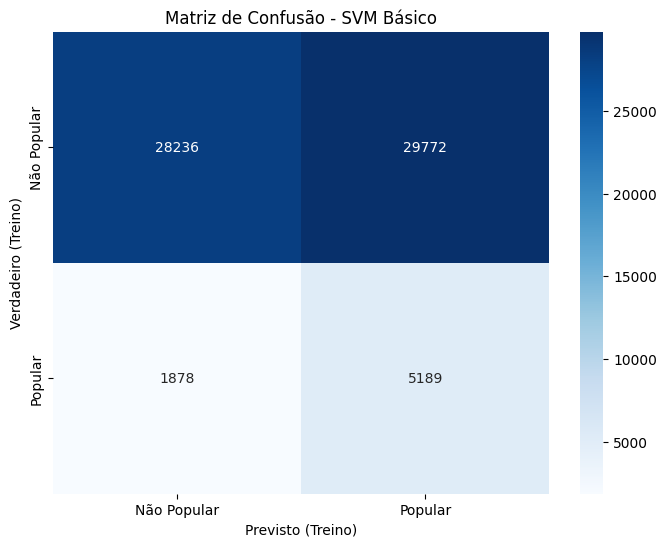


Métricas de Classificação (Treino - SVM Básico:
              precision    recall  f1-score   support

 Não Popular       0.94      0.49      0.64     58008
     Popular       0.15      0.73      0.25      7067

    accuracy                           0.51     65075
   macro avg       0.54      0.61      0.44     65075
weighted avg       0.85      0.51      0.60     65075



In [9]:
y_pred = modelo.predict(x_train)  


conf_matrix_modelo = confusion_matrix(y_train, y_pred)
print(f"Matriz de Confusão (Treino - {nome_modelo}):")
print(conf_matrix_modelo)

# Cria uma figura para exibir graficamente a matriz de confusão do teste
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_modelo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],   # Rótulos das classes previstas
            yticklabels=['Não Popular', 'Popular'])   # Rótulos das classes reais
plt.xlabel('Previsto (Treino)')                        # Eixo X: classe prevista
plt.ylabel('Verdadeiro (Treino)')                      # Eixo Y: classe real
plt.title(f'Matriz de Confusão - {nome_modelo}')         # Título do gráfico
plt.show()

# Exibe as métricas de desempenho: precisão, recall, F1-score e suporte
print(f"\nMétricas de Classificação (Treino - {nome_modelo}:")
print(classification_report(y_train, y_pred, target_names=['Não Popular', 'Popular']))